In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from arch import arch_model
from arch.unitroot import PhillipsPerron
from mgarch import mgarch

array([<AxesSubplot: xlabel='date'>, <AxesSubplot: xlabel='date'>,
       <AxesSubplot: xlabel='date'>, <AxesSubplot: xlabel='date'>,
       <AxesSubplot: xlabel='date'>, <AxesSubplot: xlabel='date'>],
      dtype=object)

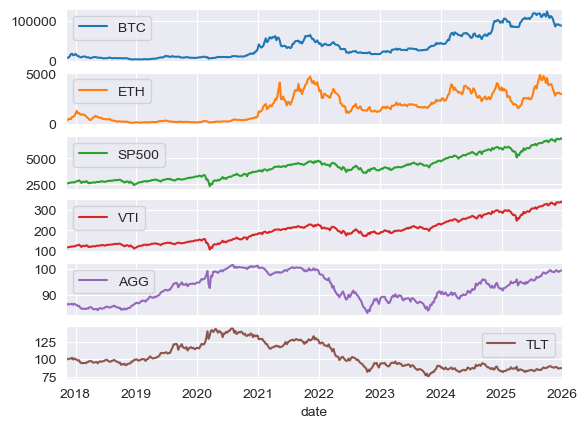

In [6]:
# initialize dataframe with eth has it has the shortest date range
df = pd.read_csv("data/merged_data_v2.csv", index_col='date')
df.dropna(inplace=True)
df.index= pd.to_datetime(df.index, format = '%Y-%m-%d')
weekly_df = df[["btc_adj_close", "eth_adj_close", "sp500_adj_close", "vti_adj_close", "agg_adj_close", "tlt_adj_close"]].resample("W-FRI").last().dropna()
weekly_df.columns = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"]
weekly_df.plot(subplots=True)

In [7]:
price_assets = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"] # treasury yield is in rates, will be treated differently
weekly_logret = 100*np.log(weekly_df[price_assets] / weekly_df[price_assets].shift(1)).dropna()
weekly_logret.head()

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-11-17,15.257283,10.503171,-0.133689,0.075436,0.293187,1.828406
2017-11-24,6.827321,35.680639,0.909815,1.102154,0.201041,0.323888
2017-12-01,28.501417,-1.778366,1.517771,1.450908,-0.126364,0.006651
2017-12-08,41.188305,-2.278298,0.350606,0.300880,0.027496,0.110650
2017-12-15,6.639677,40.605187,0.912664,0.780918,0.256074,1.301692


In [8]:
print(f"Weekly obs : {len(weekly_logret)}")
print(f"Date range : {weekly_logret.index[0].date()} → {weekly_logret.index[-1].date()}")
print(f"\nMissing values:\n{weekly_logret.isnull().sum()}")
print(f"\nDescriptive stats:\n{weekly_logret.describe().round(4)}")
# as expected, volatility of crypto>stocks>bonds

Weekly obs : 425
Date range : 2017-11-17 → 2026-01-02

Missing values:
BTC      0
ETH      0
SP500    0
VTI      0
AGG      0
TLT      0
dtype: int64

Descriptive stats:
            BTC       ETH     SP500       VTI       AGG       TLT
count  425.0000  425.0000  425.0000  425.0000  425.0000  425.0000
mean     0.6075    0.5398    0.2294    0.2492    0.0335   -0.0301
std      9.3644   12.0246    2.5695    2.6347    0.7719    2.0308
min    -49.4484  -60.3355  -16.2279  -16.5557   -5.2249   -8.0052
25%     -3.5334   -5.6784   -1.0172   -1.0605   -0.3462   -1.1682
50%      0.3681    0.2524    0.4872    0.5327    0.0566    0.0790
75%      5.0951    7.0441    1.6065    1.6849    0.4084    1.1863
max     41.1883   50.6363   11.4237   12.1792    4.9123    7.2667


## GARCH Volatility Modelling

In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from arch import arch_model
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox


# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

from dataclasses import dataclass, field
from typing import List  # used in GARCHConfig field annotations
# Note: uses print() for output throughout


@dataclass
class GARCHConfig:
    """
    Central configuration for the GARCH pipeline.
    Override defaults by passing GARCHConfig(arch_lags=8) etc.
    """
    arch_lags:              int   = 12           # Using weekly data, lags are taken to be 3 months/ one quarter
    lb_lags:                list  = field(default_factory=lambda: [10, 20]) # test at lag 10 (short term) and 20 (medium term)
    test_size:              int   = 52           # 1 year
    significance_level:     float = 0.05
    skewness_threshold:     float = 0.5
    kurtosis_threshold:     float = 1.0
#     convergence_tolerance:  float = 1e-10
#     boundary_threshold:     float = 1e-6
    bic_tolerance:          float = 2.0   # Kass & Raftery (1995): ΔBIC < 2 is not worth mentioning
                                          # GED accepted if BIC(GED) <= BIC(skewt) + bic_tolerance
                                          # AND kurtosis improves. 
    refit_frequency:        int   = 1     # OOS refit: 1=every step (Hansen & Lunde 2005 standard)

# Default config instance — functions use this unless overridden
DEFAULT_CONFIG = GARCHConfig()


# ARCH LM TEST

def arch_lm_test(resid: pd.Series, lags: int = 12,
                 label: str = "") -> dict:
    """
    Engle (1982) ARCH LM test. Default lags=12 for weekly data.
    H0: no ARCH effects.
    Run post-fit.
    """
    arr = np.asarray(resid.dropna(), dtype=float)
    lm_stat, lm_pval, f_stat, f_pval = het_arch(arr, nlags=lags)

    sig = "no ARCH effects" if lm_pval > 0.05 else "ARCH effects remain"
    print(f"  ARCH LM [{label}]  "
          f"LM={lm_stat:.4f}  p={lm_pval:.4f}  "
          f"F={f_stat:.4f}  p={f_pval:.4f}  ->  {sig}")

    return {"lm_stat": lm_stat, "lm_pvalue": lm_pval,
            "f_stat":  f_stat,  "f_pvalue":  f_pval,
            "success": True}



# NORMALITY / TAIL CHECK
def normality_tail_check(std_resid: pd.Series,
                          dist_used: str = "skewt",
                          result=None,
                          label: str = "",
                          config: GARCHConfig = None) -> dict:
    """
    Normality and tail diagnostics on standardised residuals z_t = e_t / sigma_t.

    Distribution-aware interpretation:
      normal : JB and KS vs normal are fully valid
      skewt  : JB informational only (non-normal by design)
               KS run against fitted t(df=nu) — correct benchmark
               Excess kurtosis is the primary diagnostic
      ged    : JB informational only; excess kurtosis is primary diagnostic
               KS vs normal shown as reference only
    """
    from scipy.stats import t as student_t

    if config is None:
        config = DEFAULT_CONFIG
    arr = np.asarray(std_resid.dropna(), dtype=float)
    n   = len(arr)

    jb_stat, jb_pval           = stats.jarque_bera(arr)
    skew                       = stats.skew(arr)
    kurt                       = stats.kurtosis(arr)
    arr_std                    = (arr - arr.mean()) / arr.std()
    ks_norm_stat, ks_norm_pval = stats.kstest(arr_std, "norm")

    print(f"\n  Normality / tail check [{label}]")
    print(f"  {'Obs':<32}: {n}")
    print(f"  {'Skewness':<32}: {skew:.4f}  "
          + ("(notable asymmetry)" if abs(skew) > config.skewness_threshold else "(ok)"))
    print(f"  {'Excess kurtosis':<32}: {kurt:.4f}  "
          + ("(fat tails remain)" if kurt > config.kurtosis_threshold else "(ok)"))

    # Jarque-Bera
    if dist_used == "normal":
        jb_label = "FAIL" if jb_pval < config.significance_level else "ok"
    else:
        jb_label = f"informational only ({dist_used} is non-normal by design)"
    print(f"  {'Jarque-Bera':<32}: stat={jb_stat:.4f}  p={jb_pval:.4f}  [{jb_label}]")

    # KS test — benchmark depends on distribution
    if dist_used == "normal":
        ks_label = "FAIL" if ks_norm_pval < config.significance_level else "ok"
        print(f"  {'KS vs normal':<32}: stat={ks_norm_stat:.4f}  "
              f"p={ks_norm_pval:.4f}  [{ks_label}]")

    elif dist_used == "skewt":
        print(f"  {'KS vs normal (ref only)':<32}: stat={ks_norm_stat:.4f}  "
              f"p={ks_norm_pval:.4f}  [not meaningful for skewt]")
        if result is not None:
            try:
                nu = result.params.get("nu", None)
                if nu is not None and float(nu) > 2:
                    # Approximation: skewt != symmetric t.
                    # t(df=nu) captures tail thickness but ignores
                    # the skewness dimension of the skewt distribution.
                    ks_t_stat, ks_t_pval = stats.kstest(
                        arr_std,
                        lambda x: student_t.cdf(x, df=float(nu))
                    )
                    ks_t_label = "ok" if ks_t_pval > config.significance_level else "poor fit"
                    print(f"  {'KS vs t(df=' + f'{float(nu):.1f})':<32}: "
                          f"stat={ks_t_stat:.4f}  p={ks_t_pval:.4f}  "
                          f"[{ks_t_label}] (primary test for skewt)")
                else:
                    print(f"  KS vs t: nu={nu} -- cannot run (df <= 2)")
            except Exception as e:
                print(f"  KS vs t: skipped ({e})")
        else:
            print(f"  KS vs t(nu): pass result= to enable")

    elif dist_used == "ged":
        print(f"  {'KS vs normal (ref only)':<32}: stat={ks_norm_stat:.4f}  "
              f"p={ks_norm_pval:.4f}  [reference only for GED]")

    # Excess kurtosis guidance
    if dist_used in ("skewt", "ged"):
        if kurt > 3.0:
            print(f"  [!] Excess kurtosis={kurt:.2f} -- very heavy tails after "
                  f"{dist_used}, report as limitation")
        elif kurt > config.kurtosis_threshold:
            print(f"  [i] Excess kurtosis={kurt:.2f} -- mild fat tails remain "
                  f"after {dist_used}" +
                  (" -- GED refit will be attempted" if dist_used == "skewt" else ""))
        else:
            print(f"  [ok] {dist_used} distribution adequate")
    else:
        if kurt > config.kurtosis_threshold:
            print(f"  [!] Excess kurtosis={kurt:.2f} -- consider skewt or ged")
        else:
            print(f"  [ok] Normal distribution adequate")

    return {
        "skewness":        skew,
        "excess_kurtosis": kurt,
        "jb_stat":         jb_stat,
        "jb_pvalue":       jb_pval,
        "ks_stat":         ks_norm_stat,
        "ks_pvalue":       ks_norm_pval,
        "fat_tails_flag":  kurt > config.kurtosis_threshold,
        "asymmetry_flag":  abs(skew) > config.skewness_threshold,
        "success":         True,
    }


# 4. INTERNAL HELPERS
def _fit_model(returns_series: pd.Series,
               vol: str, dist: str,
               mean: str = "Constant") -> object:
    """
    Fit a single vol model with convergence retry.

    Parameters
    ----------
    vol  : 'GARCH' | 'GJR' | 'EGARCH'
    dist : 'skewt' | 'ged' | 'normal'
    mean : 'Constant' (default) | 'AR'
           Use 'AR' with lags=1 when returns show serial autocorrelation.
           Prevents volatility absorbing mean dynamics.
    """
    mean_lags = [1] if mean == "AR" else None

    if vol == "EGARCH":
        am = arch_model(returns_series, mean=mean, lags=mean_lags,
                        vol="EGARCH", p=1, o=1, q=1, dist=dist)
    elif vol == "GJR":
        am = arch_model(returns_series, mean=mean, lags=mean_lags,
                        vol="GARCH",  p=1, o=1, q=1, dist=dist)
    else:
        am = arch_model(returns_series, mean=mean, lags=mean_lags,
                        vol="GARCH",  p=1, o=0, q=1, dist=dist)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = am.fit(disp="off", show_warning=False)

    if result.convergence_flag != 0:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result = am.fit(disp="off", show_warning=False,
                            options={"ftol": 1e-10, "gtol": 1e-8})

    return result


def _stationarity_label(result, vol: str) -> tuple:
    """
    Return (persistence_value, persistence_label, is_stationary).
    EGARCH: |beta| < 1
    GJR   : alpha + gamma/2 + beta < 1
    GARCH : alpha + beta < 1
    """
    params = result.params
    alpha  = params.get("alpha[1]", np.nan)
    beta   = params.get("beta[1]",  np.nan)
    gamma  = params.get("gamma[1]", np.nan)

    if vol == "EGARCH":
        val   = abs(beta) if not np.isnan(beta) else np.nan
        label = "|beta|"
    elif vol == "GJR":
        val   = alpha + 0.5 * gamma + beta if not np.isnan(gamma) else np.nan
        label = "alpha+gamma/2+beta"
    else:
        val   = alpha + beta
        label = "alpha+beta"

    return val, label, (val < 1.0 if not np.isnan(val) else False)


def _persistence_interpretation(val: float) -> str:
    """
    Human-readable persistence label with half-life in weeks.

    Thresholds (GARCH literature):
      >= 0.98 : near-IGARCH — shocks almost permanent
      >= 0.90 : highly persistent — typical for equity/crypto
      >= 0.70 : moderately persistent
      <  0.70 : low persistence — rapid mean reversion
    """
    if np.isnan(val):
        return "unknown"
    if val <= 0 or val >= 1:
        hl_str = "infinite" if val >= 1 else "N/A"
    else:
        half_life = np.log(0.5) / np.log(val)
        hl_str    = f"half-life ~{half_life:.0f} weeks"

    if val >= 0.98:
        return f"near-IGARCH -- shocks near-permanent ({hl_str})"
    elif val >= 0.90:
        return f"highly persistent ({hl_str})"
    elif val >= 0.70:
        return f"moderately persistent ({hl_str})"
    else:
        return f"low persistence -- rapid mean reversion ({hl_str})"


def _check_boundary(result) -> bool:
    """
    Detect degenerate boundary solutions.

    Fix C: now checks alpha, beta, AND gamma — not just beta.
    Rules:
      beta  ~= 0 alone        -> always degenerate (no persistence)
      alpha ~= 0 AND gamma ~= 0 -> asymmetric model with no shock response
      alpha ~= 0 alone        -> not flagged (could be valid low-ARCH regime)
      gamma ~= 0 alone        -> not flagged (just means no asymmetry)
    """
    params = result.params
    flags  = []

    for key in ["alpha[1]", "beta[1]", "gamma[1]"]:
        val = params.get(key, None)
        if val is not None and abs(float(val)) < 1e-6:
            flags.append(key)

    if "beta[1]" in flags:
        print(f"  Boundary solution detected: {', '.join(flags)} ~= 0")
        return True

    if "alpha[1]" in flags and "gamma[1]" in flags:
        print(f"  Boundary solution: alpha and gamma both ~= 0")
        return True

    return False


def _run_postfit_diagnostics(std_resid: pd.Series,
                              result,
                              model_label: str,
                              dist_used: str,
                              asset_name: str,
                              config: GARCHConfig = None) -> tuple:
    """
    Consolidated post-fit diagnostics.
    Runs Ljung-Box on resid and resid², ARCH LM, normality check.
    Returns (arch_post_dict, norm_dict).
    Called for both the skewt winner and the GED refit.
    """
    if config is None:
        config = DEFAULT_CONFIG
    lb_lags = config.lb_lags
    lb_r  = acorr_ljungbox(std_resid,    lags=lb_lags, return_df=True)
    lb_r2 = acorr_ljungbox(std_resid**2, lags=lb_lags, return_df=True)
    print(f"  Ljung-Box resid   p@{lb_lags[0]}={lb_r['lb_pvalue'].loc[lb_lags[0]]:.4f}  "
          f"p@{lb_lags[1]}={lb_r['lb_pvalue'].loc[lb_lags[1]]:.4f}")
    print(f"  Ljung-Box resid^2 p@{lb_lags[0]}={lb_r2['lb_pvalue'].loc[lb_lags[0]]:.4f}  "
          f"p@{lb_lags[1]}={lb_r2['lb_pvalue'].loc[lb_lags[1]]:.4f}")
    if lb_r2['lb_pvalue'].loc[lb_lags[0]] < config.significance_level:
        print(f"  [!] Remaining ARCH effects in resid^2")

    arch_post = arch_lm_test(std_resid, lags=config.arch_lags,
                              label=f"std residuals -- post {model_label}")
    norm_res  = normality_tail_check(
        std_resid, dist_used=dist_used,
        result=result, label=asset_name,
        config=config
    )
    return arch_post, norm_res



# MODEL COMPETITION — fit all three, select by BIC
def compete_models(returns_series: pd.Series,
                   dist: str = "skewt") -> dict:
    """
    Fit GARCH(1,1), GJR-GARCH(1,1,1), EGARCH(1,1,1) with skewt.
    If any model fails or hits a boundary with skewt, retry with GED
    before excluding it — ensuring all three structures get a fair chance.

    Selection order per model:
      1. Try skewt
      2. If failed/boundary -> retry with GED
      3. If still failed -> exclude from competition

    Final competition uses BIC across all valid fits (may mix skewt + GED).

    Fix D: mean equation auto-detected via Ljung-Box on raw returns at lag 1.
    p < 0.10 -> AR(1) mean to prevent volatility absorbing mean dynamics.
    """
    # Auto-detect mean structure
    lb_mean   = acorr_ljungbox(returns_series.dropna(), lags=[1], return_df=True)
    use_ar    = lb_mean["lb_pvalue"].iloc[0] < 0.10
    mean_spec = "AR" if use_ar else "Constant"
    if use_ar:
        print(f"  AR(1) mean detected (LB p={lb_mean['lb_pvalue'].iloc[0]:.4f})"
              f" -- using AR(1) mean equation")
    else:
        print(f"  No serial correlation (LB p={lb_mean['lb_pvalue'].iloc[0]:.4f})"
              f" -- using Constant mean")

    candidates = {}
    print(f"\n  Model competition [primary={dist}, mean={mean_spec}]:")
    print(f"  {'Model':<16} {'Dist':<8} {'AIC':>10} {'BIC':>10} {'Status':>10}")
    print(f"  {'-'*56}")

    for vol in ["GARCH", "GJR", "EGARCH"]:
        fitted_dist = dist
        res         = None
        status      = ""

        # Step 1: try with primary distribution (skewt)
        try:
            res      = _fit_model(returns_series, vol, dist, mean=mean_spec)
            boundary = _check_boundary(res) if vol in ("GJR", "EGARCH") else False

            if boundary or res.convergence_flag != 0:
                reason = "boundary" if boundary else "no convergence"
                print(f"  {vol:<16} {dist:<8} {'--':>10} {'--':>10} "
                      f"  {reason} -> retrying with GED")
                res = None   # trigger GED retry below

        except Exception as e:
            print(f"  {vol:<16} {dist:<8} {'--':>10} {'--':>10}  failed ({e}) -> retrying with GED")
            res = None

        # Step 2: if skewt failed/boundary, retry with GED
        if res is None:
            fitted_dist = "ged"
            try:
                res      = _fit_model(returns_series, vol, "ged", mean=mean_spec)
                boundary = _check_boundary(res) if vol in ("GJR", "EGARCH") else False
                if boundary:
                    print(f"  {vol:<16} {'ged':<8} {'--':>10} {'--':>10}  boundary on GED too -- excluded")
                    candidates[vol] = None
                    continue
                status = "GED fallback"
            except Exception as e:
                print(f"  {vol:<16} {'ged':<8} {'--':>10} {'--':>10}  GED also failed ({e}) -- excluded")
                candidates[vol] = None
                continue
        else:
            status = "ok" if res.convergence_flag == 0 else "~converged"

        candidates[vol] = {
            "result":    res,
            "aic":       res.aic,
            "bic":       res.bic,
            "dist":      fitted_dist,     # tracks which dist was actually used
            "converged": res.convergence_flag == 0,
            "boundary":  False,           # already excluded boundaries above
        }
        print(f"  {vol:<16} {fitted_dist:<8} {res.aic:>10.2f} {res.bic:>10.2f} {status:>10}")

    # Filter out any remaining None entries
    valid = {k: v for k, v in candidates.items() if v is not None}

    if not valid:
        print(f"  All models failed -- falling back to GARCH-skewt")
        res = _fit_model(returns_series, "GARCH", dist, mean=mean_spec)
        valid = {"GARCH": {"result": res, "aic": res.aic, "bic": res.bic,
                            "dist": dist, "converged": True, "boundary": False}}

    winner_name = min(valid, key=lambda k: valid[k]["bic"])
    winner      = valid[winner_name]

    print(f"\n  -> BIC selects: {winner_name}-{winner['dist'].upper()}  "
          f"(BIC={winner['bic']:.2f})")

    return {
        "candidates": candidates,
        "winner":     winner_name,
        "winner_dist": winner["dist"],    # dist actually used by winner
        "result":     winner["result"],
        "aic":        winner["aic"],
        "bic":        winner["bic"],
        "mean_spec":  mean_spec,
    }


# ══════════════════════════════════════════════════════════════════════════════
# 6. FIT GARCH — full pipeline
# ══════════════════════════════════════════════════════════════════════════════

def fit_garch(returns_series: pd.Series,
              model_type: str = "auto",
              dist: str = "skewt") -> dict:
    """
    Full GARCH fitting pipeline with model competition and diagnostics.

    Steps:
      1. Compete GARCH / GJR / EGARCH with skewt -> select by BIC
         Mean equation auto-detected (Constant vs AR(1))
      2. Post-fit diagnostics on winner (LB + ARCH LM + normality)
      3. If fat tails remain AND winner used skewt -> refit same structure with GED
         Competition already handles GED fallback for non-converging models,
         so this step only applies when skewt won cleanly but has fat tails.
         Keep GED only if BIC improves AND kurtosis reduces
    """
    print(f"\n  {'--'*25}")

    # Step 1: model competition (skewt only)
    # Pre-fit ARCH LM removed (Fix B) -- overlaps with post-fit LB on resid^2
    if model_type != "auto":
        print(f"\n  Manual override: fitting {model_type} only")
        lb_mean      = acorr_ljungbox(returns_series.dropna(), lags=[1], return_df=True)
        mean_spec    = "AR" if lb_mean["lb_pvalue"].iloc[0] < 0.10 else "Constant"
        result       = _fit_model(returns_series, model_type.upper(), dist,
                                  mean=mean_spec)
        chosen       = model_type.upper()
        current_dist = dist
        comp_candidates = {}
    else:
        comp            = compete_models(returns_series, dist=dist)
        result          = comp["result"]
        chosen          = comp["winner"]
        current_dist    = comp["winner_dist"]  # actual dist used (skewt or GED fallback)
        mean_spec       = comp["mean_spec"]    # carry forward for GED refit
        comp_candidates = comp["candidates"]

    # Step 3: stationarity check with interpretation (Fix E)
    persist_val, persist_label, is_stationary = _stationarity_label(result, chosen)
    interp = _persistence_interpretation(persist_val)
    status = "stationary" if is_stationary else "NON-STATIONARY"
    print(f"  {chosen} {persist_label}={persist_val:.4f}  ->  {status}  |  {interp}")

    # Step 4: post-fit diagnostics on skewt winner
    cond_var  = result.conditional_volatility ** 2
    std_resid = result.std_resid.dropna()

    print(f"\n  Post-fit [{chosen}-{current_dist.upper()}]:")
    arch_post, norm_results = _run_postfit_diagnostics(
        std_resid, result,
        model_label=chosen,
        dist_used=current_dist,
        asset_name=returns_series.name,
        config=DEFAULT_CONFIG
    )

    # Step 5: GED refit of winning structure only (Fix A)
    # Do NOT re-run full competition -- structure is fixed, test distribution only
    final_dist      = current_dist
    final_result    = result
    final_norm      = norm_results
    final_arch_post = arch_post

    if current_dist == "skewt" and norm_results["fat_tails_flag"]:
        # Only attempt GED refit if winner used skewt in competition.
        # If competition already fell back to GED for this model, skip.
        print(f"\n  -> Refitting {chosen} with GED (distribution test only) ...")
        result_ged = _fit_model(returns_series, chosen, "ged", mean=mean_spec)

        if not _check_boundary(result_ged):
            std_resid_ged = result_ged.std_resid.dropna()

            # Run full adequacy check on refitted model
            print(f"\n  Post-fit [{chosen}-GED]:")
            arch_post_ged, norm_ged = _run_postfit_diagnostics(
                std_resid_ged, result_ged,
                model_label=f"{chosen}-GED",
                dist_used="ged",
                asset_name=returns_series.name,
                config=DEFAULT_CONFIG
            )

            # BIC-based acceptance with Kass & Raftery (1995) tolerance
            # ΔBIC < 2 is "not worth mentioning" — allow GED if kurtosis
            # improves meaningfully even with a small BIC cost
            bic_delta     = result_ged.bic - result.bic
            bic_improves  = bic_delta <= DEFAULT_CONFIG.bic_tolerance
            kurt_improves = norm_ged["excess_kurtosis"] < norm_results["excess_kurtosis"]

            if bic_improves and kurt_improves:
                print(f"  GED-{chosen} accepted: "
                      f"ΔBIC={bic_delta:+.2f} (tol={DEFAULT_CONFIG.bic_tolerance})  |  "
                      f"BIC {result.bic:.2f} -> {result_ged.bic:.2f}  |  "
                      f"AIC {result.aic:.2f} -> {result_ged.aic:.2f}  |  "
                      f"Kurt {norm_results['excess_kurtosis']:.2f} "
                      f"-> {norm_ged['excess_kurtosis']:.2f}")
                final_dist      = "ged"
                final_result    = result_ged
                final_norm      = norm_ged       # adequacy check of GED model
                final_arch_post = arch_post_ged  # arch LM of GED model
                cond_var        = result_ged.conditional_volatility ** 2
                std_resid       = result_ged.std_resid.dropna()
            elif not bic_improves and kurt_improves:
                print(f"  GED reduces kurtosis but ΔBIC={bic_delta:+.2f} "
                      f"exceeds tolerance ({DEFAULT_CONFIG.bic_tolerance}) "
                      f"-- keeping {chosen}-skewt.")
            else:
                print(f"  GED does not improve fit -- keeping {chosen}-skewt.")
        else:
            print(f"  GED boundary solution -- keeping {chosen}-skewt.")

    # Unconditional (long-run) variance
    uncond_var = float(cond_var.mean())

    print(f"\n  Final model: {chosen}(1,1)-{final_dist.upper()}  "
          f"AIC={final_result.aic:.2f}  BIC={final_result.bic:.2f}")
    print(final_result.summary().tables[1])

    return {
        "model_type":       chosen,
        "dist":             final_dist,
        "result":           final_result,
        "cond_vol":         final_result.conditional_volatility,
        "cond_var":         cond_var,
        "uncond_var":       uncond_var,
        "uncond_vol":       np.sqrt(uncond_var),
        "std_resid":        std_resid,
        "aic":              final_result.aic,
        "bic":              final_result.bic,
        "arch_post":        final_arch_post,
        "normality":        final_norm,
        "persist_val":      persist_val,
        "persist_label":    persist_label,
        "persist_interp":   interp,
        "comp_candidates":  comp_candidates,
        "mean_spec":        mean_spec,       # stored for OOS consistency
    }


# ══════════════════════════════════════════════════════════════════════════════
# 7. FIT ALL ASSETS
# ══════════════════════════════════════════════════════════════════════════════

def fit_all_garch(returns: pd.DataFrame,
                  model_type: str = "auto") -> dict:
    """
    Fit full pipeline for every column in returns DataFrame.
    Call diagnostics_summary_table() explicitly in main file.
    """
    garch_results = {}
    for asset in returns.columns:
        print(f"\n{'='*60}")
        print(f"GARCH fit: {asset}")
        print(f"{'='*60}")
        series      = returns[asset].copy()
        series.name = asset
        try:
            garch_results[asset] = fit_garch(series, model_type=model_type)
            garch_results[asset]["success"] = True
        except Exception as e:
            print(f"  [!] Failed to fit {asset}: {e}")
            garch_results[asset] = {"success": False, "error": str(e)}
    return garch_results


# ══════════════════════════════════════════════════════════════════════════════
# 8. SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

def diagnostics_summary_table(garch_results: dict) -> pd.DataFrame:
    """
    Summary diagnostics table across all fitted assets.
    Call once in main file after fit_all_garch().

    Includes persistence interpretation (Fix E).
    pre-fit ARCH LM removed (Fix B) -- only post-fit ARCH LM reported.
    """
    rows = []
    for asset, res in garch_results.items():
        # Skip failed fits gracefully
        if not res.get("success", False):
            print(f"  [!] Skipping {asset} in summary table: {res.get('error', 'unknown error')}")
            continue
        norm      = res["normality"]
        arch_post = res["arch_post"]
        params    = res["result"].params
        model     = res["model_type"]
        dist      = res.get("dist", "skewt")

        alpha = params.get("alpha[1]", np.nan)
        beta  = params.get("beta[1]",  np.nan)
        gamma = params.get("gamma[1]", np.nan)

        persist_val   = res.get("persist_val",   np.nan)
        persist_label = res.get("persist_label", "")
        interp        = res.get("persist_interp", "")

        rows.append({
            "Asset":          asset,
            "Model":          f"{model}-{dist.upper()}",
            "alpha":          round(alpha, 4),
            "gamma":          round(gamma, 4) if not np.isnan(gamma) else "--",
            "beta":           round(beta,  4),
            "Persistence":    round(persist_val, 4),
            "Metric":         persist_label,
            "Stationary":     "OK" if persist_val < 1.0 else "WARN",
            "Interpretation": interp,
            "Skewness":       round(norm["skewness"], 4),
            "Excess Kurt":    round(norm["excess_kurtosis"], 4),
            "JB p-val":       round(norm["jb_pvalue"], 4),
            "ARCH post p":    round(arch_post["lm_pvalue"], 4),
            "AIC":            round(res["aic"], 2),
            "BIC":            round(res["bic"], 2),
        })

    df = pd.DataFrame(rows).set_index("Asset")
    print("\n-- GARCH Diagnostics Summary --")
    print(df.to_string())
    return df



# ══════════════════════════════════════════════════════════════════════════════
# 10. PARAMETER SIGNIFICANCE TABLE
# ══════════════════════════════════════════════════════════════════════════════

def parameter_significance_table(garch_results: dict) -> pd.DataFrame:
    """
    Key GARCH parameters with t-stats, p-values, significance stars.
    Suitable for direct use as a results table in your paper.
    *** p<0.01  ** p<0.05  * p<0.10
    """
    rows       = []
    param_keys = ["mu", "omega", "alpha[1]", "gamma[1]", "beta[1]", "nu"]
    display    = ["mu", "omega", "alpha",    "gamma",     "beta",    "nu"]

    for asset, res in garch_results.items():
        if not res.get("success", False):
            continue
        result = res["result"]
        params = result.params
        pvals  = result.pvalues
        tstats = result.tvalues
        model  = res["model_type"]
        dist   = res.get("dist", "skewt")

        row = {"Asset": asset, "Model": f"{model}-{dist.upper()}"}
        for key, label in zip(param_keys, display):
            val  = params.get(key, None)
            pval = pvals.get(key,  None)
            tval = tstats.get(key, None)
            if val is not None:
                sig = ("***" if pval < 0.01 else
                       "**"  if pval < 0.05 else
                       "*"   if pval < 0.10 else "")
                row[label]            = round(float(val),  4)
                row[f"{label}_tstat"] = round(float(tval), 3)
                row[f"{label}_pval"]  = round(float(pval), 4)
                row[f"{label}_sig"]   = sig
            else:
                row[label]            = "--"
                row[f"{label}_tstat"] = "--"
                row[f"{label}_pval"]  = "--"
                row[f"{label}_sig"]   = "--"
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Asset")
    print("\n-- GARCH Parameter Estimates (*** p<0.01, ** p<0.05, * p<0.10) --")
    disp_cols = (["Model"] +
                 [l for l in display] +
                 [f"{l}_sig" for l in display])
    disp_cols = [c for c in disp_cols if c in df.columns]
    print(df[disp_cols].to_string())
    df.to_csv("garch_parameters.csv")
    print("Saved: garch_parameters.csv")
    return df


# ══════════════════════════════════════════════════════════════════════════════
# 11. PLOTS
# ══════════════════════════════════════════════════════════════════════════════

def plot_conditional_volatility(garch_results: dict,
                                 psy_results: dict,
                                 save_path: str = "03_conditional_volatility.png"):
    """Conditional volatility for all assets with bubble episode shading."""
    assets = list(garch_results.keys())
    fig, axes = plt.subplots(len(assets), 1,
                             figsize=(16, 3 * len(assets)), sharex=True)
    if len(assets) == 1:
        axes = [axes]

    for ax, asset in zip(axes, assets):
        cv   = garch_results[asset]["cond_vol"]
        dist = garch_results[asset].get("dist", "skewt")
        mod  = garch_results[asset]["model_type"]

        ax.fill_between(cv.index, cv.values, alpha=0.6,
                        color="steelblue", label=f"{asset} sigma_t")
        ax.set_ylabel("Cond. vol (%)")
        ax.set_title(f"{asset} -- {mod}(1,1)-{dist.upper()}")

        if psy_results and asset in psy_results and "episodes" in psy_results[asset]:
            for k, (s, e) in enumerate(psy_results[asset]["episodes"]):
                ax.axvspan(s, e, alpha=0.18, color="crimson",
                           label="bubble" if k == 0 else "")
        ax.legend(fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"Saved: {save_path}")


def plot_garch_diagnostics(garch_results: dict,
                            save_path: str = "04_garch_diagnostics.png"):
    """
    Four-panel diagnostic plot per asset:
      1. Standardised residuals over time
      2. ACF of standardised residuals
      3. ACF of squared standardised residuals
      4. QQ plot vs fitted distribution (t(df=nu) for skewt, normal otherwise)
    """
    from statsmodels.graphics.tsaplots import plot_acf
    from scipy.stats import t as student_t, norm as sp_norm

    assets   = list(garch_results.keys())
    if len(assets) > 8:
        print(f"  [i] Limiting diagnostic plot to first 8 assets")
        assets = assets[:8]
    n_assets = len(assets)

    fig, axes = plt.subplots(n_assets, 4, figsize=(20, 4 * n_assets))
    if n_assets == 1:
        axes = [axes]

    for row, asset in enumerate(assets):
        res       = garch_results[asset]
        std_resid = res["std_resid"]
        model     = res["model_type"]
        dist      = res.get("dist", "skewt")
        params    = res["result"].params
        nu        = float(params.get("nu", 5))
        ax1, ax2, ax3, ax4 = axes[row]

        # Panel 1: residuals over time
        ax1.plot(std_resid.index, std_resid.values,
                 lw=0.5, color="steelblue", alpha=0.8)
        ax1.axhline(0,   lw=0.8, color="black")
        ax1.axhline( 3,  lw=0.8, color="crimson", linestyle="--", alpha=0.6)
        ax1.axhline(-3,  lw=0.8, color="crimson", linestyle="--", alpha=0.6,
                    label="+-3 sigma")
        ax1.set_title(f"{asset} -- Std residuals", fontsize=9)
        ax1.set_ylabel("z_t")
        ax1.legend(fontsize=7)
        ax1.annotate(f"{model}-{dist.upper()}",
                     xy=(0.02, 0.93), xycoords="axes fraction",
                     fontsize=8, color="darkblue")

        # Panel 2: ACF of residuals
        plot_acf(std_resid.dropna(), lags=20, ax=ax2,
                 alpha=0.05, zero=False, color="steelblue")
        ax2.set_title(f"{asset} -- ACF(z_t)", fontsize=9)
        ax2.set_xlabel("Lag")

        # Panel 3: ACF of squared residuals
        plot_acf(std_resid.dropna()**2, lags=20, ax=ax3,
                 alpha=0.05, zero=False, color="darkorange")
        ax3.set_title(f"{asset} -- ACF(z_t^2)", fontsize=9)
        ax3.set_xlabel("Lag")

        # Panel 4: QQ plot vs fitted distribution
        arr   = np.sort(std_resid.dropna().values)
        n     = len(arr)
        probs = (np.arange(1, n + 1) - 0.5) / n

        if dist in ("skewt", "ged") and nu > 2:
            theor    = student_t.ppf(probs, df=nu)
            qq_label = f"t(df={nu:.1f}) quantiles"
        else:
            theor    = sp_norm.ppf(probs)
            qq_label = "Normal quantiles"

        ax4.scatter(theor, arr, s=4, color="steelblue", alpha=0.6)
        q25, q75 = np.percentile(arr,   [25, 75])
        t25, t75 = np.percentile(theor, [25, 75])
        slope     = (q75 - q25) / (t75 - t25) if abs(t75 - t25) > 1e-10 else 1.0
        intercept = q25 - slope * t25
        x_line   = np.array([theor.min(), theor.max()])
        ax4.plot(x_line, slope * x_line + intercept,
                 color="crimson", lw=1.2, label="Reference line")
        ax4.set_title(f"{asset} -- QQ vs {qq_label}", fontsize=9)
        ax4.set_xlabel(qq_label)
        ax4.set_ylabel("Sample quantiles")
        ax4.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {save_path}")


def plot_news_impact_curve(garch_results: dict,
                            save_path: str = "05_news_impact_curve.png"):
    """
    News Impact Curve (Engle & Ng 1993).
    Shows asymmetric volatility response to positive vs negative shocks.
    Steep left side confirms leverage effect detected by sign-bias test.
    """
    assets   = list(garch_results.keys())
    n_assets = len(assets)
    z_range  = np.linspace(-4, 4, 300)

    fig, axes = plt.subplots(1, n_assets,
                              figsize=(5 * n_assets, 4), sharey=False)
    if n_assets == 1:
        axes = [axes]

    for ax, asset in zip(axes, assets):
        res        = garch_results[asset]
        model      = res["model_type"]
        dist       = res.get("dist", "skewt")
        params     = res["result"].params
        sigma2_bar = float(res["cond_var"].mean())

        try:
            omega = float(params.get("omega",    0))
            alpha = float(params.get("alpha[1]", 0))
            beta  = float(params.get("beta[1]",  0))
            gamma = float(params.get("gamma[1]", 0))

            if model == "EGARCH":
                e_abs_z = np.sqrt(2 / np.pi)
                log_nic = (omega
                           + alpha * (np.abs(z_range) - e_abs_z)
                           + gamma * z_range
                           + beta  * np.log(max(sigma2_bar, 1e-10)))
                nic = np.exp(log_nic)
            elif model == "GJR":
                ind_neg = (z_range < 0).astype(float)
                nic = (alpha + gamma * ind_neg) * z_range**2 + beta * sigma2_bar
            else:
                nic = alpha * z_range**2 + beta * sigma2_bar

            mid     = len(nic) // 2
            nic_norm = nic / max(nic[mid], 1e-10)

            ax.plot(z_range[z_range < 0],  nic_norm[z_range < 0],
                    color="crimson",   lw=1.5, label="Negative shock")
            ax.plot(z_range[z_range >= 0], nic_norm[z_range >= 0],
                    color="steelblue", lw=1.5, label="Positive shock")
            ax.axvline(0, lw=0.6, color="black", linestyle="--")

        except Exception as e:
            ax.text(0.5, 0.5, f"NIC failed:\n{e}",
                    transform=ax.transAxes, ha="center", fontsize=8)

        ax.set_title(f"{asset}\n{model}-{dist.upper()}", fontsize=9)
        ax.set_xlabel("Shock size (z)")
        ax.set_ylabel("Normalised variance response")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, lw=0.5)

    plt.suptitle("News Impact Curves -- asymmetric volatility response",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {save_path}")


def plot_all_diagnostics(garch_results: dict, psy_results: dict):
    """
    Convenience wrapper -- runs all diagnostic plots.
    Call once in main file after fit_all_garch().

    Outputs:
      03_conditional_volatility.png
      04_garch_diagnostics.png
      05_news_impact_curve.png
    """
    print("\nGenerating diagnostic plots ...")
    plot_conditional_volatility(garch_results, psy_results)
    plot_garch_diagnostics(garch_results)
    plot_news_impact_curve(garch_results)
    print("All plots saved.")


In [10]:
garch_results = fit_all_garch(weekly_logret, model_type="auto")
# plot_conditional_volatility(garch_results, psy_results, save_path="03_conditional_volatility.png")
diag_table = diagnostics_summary_table(garch_results)
cond_vol_df = pd.DataFrame({
    asset: garch_results[asset]["cond_vol"]
    for asset in garch_results
}).dropna()


GARCH fit: BTC

  --------------------------------------------------
  AR(1) mean detected (LB p=0.0843) -- using AR(1) mean equation

  Model competition [primary=skewt, mean=AR]:
  Model            Dist            AIC        BIC     Status
  --------------------------------------------------------
  GARCH            skewt       3019.33    3047.68         ok
  GJR              skewt       3013.32    3045.72         ok
  EGARCH           skewt            --         --   no convergence -> retrying with GED
  EGARCH           ged         3002.10    3030.45 GED fallback

  -> BIC selects: EGARCH-GED  (BIC=3030.45)
  EGARCH |beta|=0.9996  ->  stationary  |  near-IGARCH -- shocks near-permanent (half-life ~1574 weeks)

  Post-fit [EGARCH-GED]:
  Ljung-Box resid   p@10=0.7007  p@20=0.6338
  Ljung-Box resid^2 p@10=0.4766  p@20=0.4628
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Lib

In [11]:
parameter_significance_table(garch_results)


-- GARCH Parameter Estimates (*** p<0.01, ** p<0.05, * p<0.10) --
              Model      mu   omega   alpha   gamma    beta      nu mu_sig omega_sig alpha_sig gamma_sig beta_sig nu_sig
Asset                                                                                                                   
BTC      EGARCH-GED      -- -0.0120 -0.0436  0.0375  0.9996  1.0194     --       ***       ***        **      ***    ***
ETH       GARCH-GED  0.3394  1.5925  0.0174      --  0.9669  1.2418                                   --      ***    ***
SP500  EGARCH-SKEWT      --  0.1442  0.2013 -0.2571  0.9075      --     --       ***       ***       ***      ***     --
VTI    EGARCH-SKEWT      --  0.1430  0.2265 -0.2451  0.9119      --     --       ***       ***       ***      ***     --
AGG       GARCH-GED  0.0493  0.0299  0.2660      --  0.7070  1.3812      *         *       ***        --      ***    ***
TLT     GARCH-SKEWT      --  0.2226  0.1071      --  0.8416      --     --            

,Model,mu,mu_tstat,mu_pval,mu_sig,omega,omega_tstat,omega_pval,omega_sig,alpha,...,gamma_pval,gamma_sig,beta,beta_tstat,beta_pval,beta_sig,nu,nu_tstat,nu_pval,nu_sig
Asset,,,,,,,,,,,,,,,,,,,,,
BTC,EGARCH-GED,--,--,--,--,-0.0120,-10.204,0.0000,***,-0.0436,...,0.0418,**,0.9996,8.538326e+07,0.0,***,1.0194,4.345,0.0,***
ETH,GARCH-GED,0.3394,0.935,0.3498,,1.5925,0.890,0.3736,,0.0174,...,--,--,0.9669,2.869500e+01,0.0,***,1.2418,8.762,0.0,***
SP500,EGARCH-SKEWT,--,--,--,--,0.1442,2.589,0.0096,***,0.2013,...,0.0,***,0.9075,3.140300e+01,0.0,***,--,--,--,--
VTI,EGARCH-SKEWT,--,--,--,--,0.1430,2.657,0.0079,***,0.2265,...,0.0,***,0.9119,3.370700e+01,0.0,***,--,--,--,--
AGG,GARCH-GED,0.0493,1.758,0.0787,*,0.0299,1.821,0.0686,*,0.2660,...,--,--,0.7070,7.686000e+00,0.0,***,1.3812,9.615,0.0,***
TLT,GARCH-SKEWT,--,--,--,--,0.2226,0.799,0.4242,,0.1071,...,--,--,0.8416,6.715000e+00,0.0,***,--,--,--,--


In [12]:
garch_results['BTC']['cond_vol']

date
2017-11-17          NaN
2017-11-24    16.520411
2017-12-01    16.670928
2017-12-08    16.754382
2017-12-15    16.803804
                ...    
2025-12-05     4.682643
2025-12-12     4.648715
2025-12-19     4.695347
2025-12-26     4.646432
2026-01-02     4.666906
Freq: W-FRI, Name: cond_vol, Length: 425, dtype: float64

## Additional Tests (for reference)

In [13]:
# SIGN-BIAS TEST
# this test helps to check if leverage exists in the time series, justifying the use of asymmetric GARCH models like EGARCH or GJR-GARCH
def sign_bias_test(returns_series: pd.Series) -> dict:
    """
    Engle & Ng (1993) sign-bias test.
    Informational only — model selection is done by BIC competition.
    """
    am   = arch_model(returns_series, vol="GARCH", p=1, q=1, dist="normal")
    res  = am.fit(disp="off", show_warning=False)
    zhat = res.std_resid.dropna()

    zhat_sq  = zhat.values ** 2
    neg_ind  = (zhat.values < 0).astype(float)
    neg_zhat = neg_ind * zhat.values
    pos_zhat = (1.0 - neg_ind) * zhat.values

    X        = sm.add_constant(np.column_stack([neg_ind, neg_zhat, pos_zhat]))
    ols_res  = sm.OLS(zhat_sq, X).fit()
    p_val    = ols_res.f_pvalue
    leverage = p_val < 0.05
    
    # Individual t-tests
    sign_bias_p = ols_res.pvalues[1]  # neg_ind (check if negative and positive shocks behave differently)
    neg_sign_p  = ols_res.pvalues[2]  # neg_zhat (check if size of negative shocks cause larger volatility)
    pos_sign_p  = ols_res.pvalues[3]  # pos_zhat (check if size of positive shocks cause larger volatility)


    print(f"  Sign-bias test (Engle & Ng 1993): "
          f"F={ols_res.fvalue:.4f}  p={p_val:.4f}  "
          f"-> {'leverage likely' if leverage else 'no leverage detected'}")
    print(f"    Sign bias p={sign_bias_p:.4f}  "
          f"Neg sign bias p={neg_sign_p:.4f}  "
          f"Pos sign bias p={pos_sign_p:.4f}")

    return {"f_stat": ols_res.fvalue, "p_value": p_val, "leverage": leverage, "success": True}


In [16]:
vol_df = pd.DataFrame({
    "BTC_vol": garch_btc.conditional_volatility,
    "ETH_vol": garch_eth.conditional_volatility,
    "SP500_vol": garch_sp500.conditional_volatility,
    "VTI_vol": garch_vti.conditional_volatility,
    "AGG_vol": garch_agg.conditional_volatility,
    "TLT_vol": garch_tlt.conditional_volatility,
})

vol_df.to_csv("volatility_series.csv")

NameError: name 'garch_btc' is not defined